# NBA Team Performance Analysis

Research Question: What statistical differences exist between top-performing and average NBA teams?

This project uses Basketball Reference team statistics from five NBA seasons to compare top performing teams with average teams. I collected basic per-game statistics and advanced team statistics then used Python to clean, combine, analyze, and present the data!

                  Win%         PTS       FG%       3P%        AST        TRB  \
Category                                                                       
Average Team  0.555560  114.078313  0.473349  0.365072  25.734940  44.006024   
Top Team      0.711947  116.705556  0.482111  0.379611  26.366667  45.022222   

                    TOV       MOV       SRS        ORtg        DRtg      NRtg  
Category                                                                       
Average Team  13.663855  1.936024  1.855663  114.937349  112.975904  1.961446  
Top Team      13.183333  6.993889  6.732778  117.827778  110.766667  7.061111  


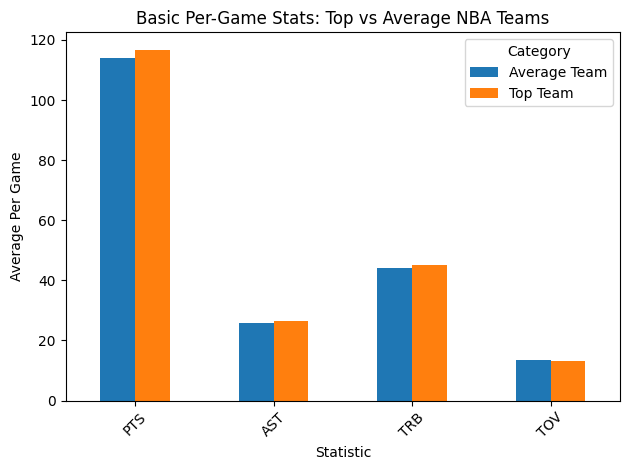

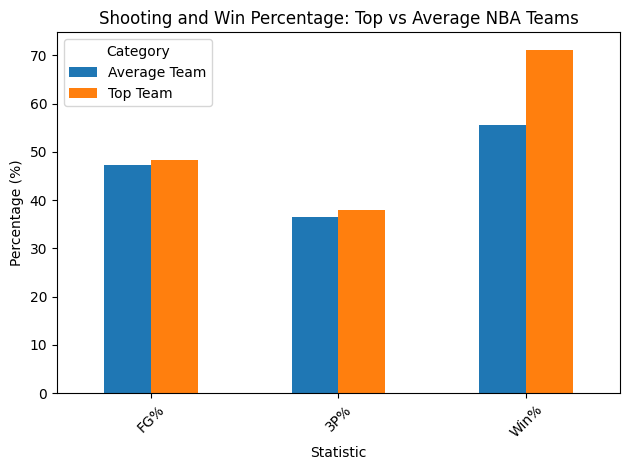

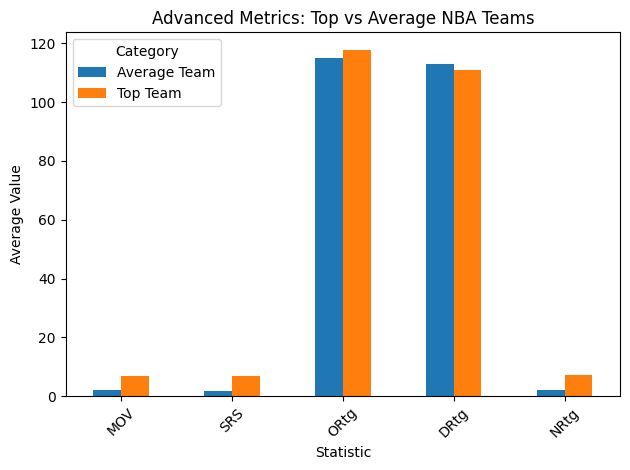

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# function for advanced files
def read_advanced_file(filename):
    columns = ["Rk", "Team", "Age", "W", "L", "PW", "PL", "MOV", "SOS", "SRS", "ORtg", "DRtg", "NRtg"]
    
    rows = []
    
    with open(filename, "r") as file:
        lines = file.readlines()
        
        for line in lines[1:]:
            values = line.strip().split(",")
            rows.append(values[:13])
    
    return pd.DataFrame(rows, columns=columns)


## upload the basic stats per season

basic_2020 = pd.read_csv("nba_basics_2020.csv")
basic_2021 = pd.read_csv("nba_basics_2021.csv")
basic_2022 = pd.read_csv("nba_basics_2022.csv")
basic_2023 = pd.read_csv("nba_basics_2023.csv")
basic_2024 = pd.read_csv("nba_basics_2024.csv")

basic_2020["Season"] = 2020
basic_2021["Season"] = 2021
basic_2022["Season"] = 2022
basic_2023["Season"] = 2023
basic_2024["Season"] = 2024

basic_df = pd.concat([basic_2020, basic_2021, basic_2022, basic_2023, basic_2024])

## now load the advanced stats to compare 

advanced_2020 = read_advanced_file("nba_advanced_2020.csv")
advanced_2021 = read_advanced_file("nba_advanced_2021.csv")
advanced_2022 = read_advanced_file("nba_advanced_2022.csv")
advanced_2023 = read_advanced_file("nba_advanced_2023.csv")
advanced_2024 = read_advanced_file("nba_advanced_2024.csv")

advanced_2020["Season"] = 2020
advanced_2021["Season"] = 2021
advanced_2022["Season"] = 2022
advanced_2023["Season"] = 2023
advanced_2024["Season"] = 2024

advanced_df = pd.concat([advanced_2020, advanced_2021, advanced_2022, advanced_2023, advanced_2024])


## clean data

basic_df.columns = basic_df.columns.str.strip()
advanced_df.columns = advanced_df.columns.str.strip()

basic_df["Team"] = basic_df["Team"].astype(str).str.replace("*", "", regex=False)
advanced_df["Team"] = advanced_df["Team"].astype(str).str.replace("*", "", regex=False)

basic_df = basic_df[basic_df["Team"] != "League Average"]
advanced_df = advanced_df[advanced_df["Team"] != "League Average"]

## now merge both data sets

nba_df = pd.merge(basic_df, advanced_df, on=["Team", "Season"])


# make the columns into numbers

columns_to_convert = [
    "W", "L", "PTS", "FG%", "3P%", "AST", "TRB", "TOV",
    "MOV", "SRS", "ORtg", "DRtg", "NRtg"
]

for column in columns_to_convert:
    nba_df[column] = pd.to_numeric(nba_df[column], errors="coerce")


# win percentage is wins / win and losses (total amount of games)

nba_df["Win%"] = nba_df["W"] / (nba_df["W"] + nba_df["L"])


# make what classifies a top team and a average team

def classify_team(win_percent):
    if win_percent >= 0.650:
        return "Top Team"
    elif win_percent >= 0.450:
        return "Average Team"
    else:
        return "Below Average"


nba_df["Category"] = nba_df["Win%"].apply(classify_team)


# comparing the top vs average team

compare_df = nba_df[nba_df["Category"].isin(["Top Team", "Average Team"])]

comparison = compare_df.groupby("Category")[[
    "Win%", "PTS", "FG%", "3P%", "AST", "TRB", "TOV",
    "MOV", "SRS", "ORtg", "DRtg", "NRtg"
]].mean()

print(comparison)


# chart/graph #1: Basic per-game stats

basic_comparison = comparison[["PTS", "AST", "TRB", "TOV"]]

basic_comparison.T.plot(kind="bar")

plt.title("Basic Per-Game Stats: Top vs Average NBA Teams")
plt.xlabel("Statistic")
plt.ylabel("Average Per Game")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## chart 2: Shooting percentages

shooting_comparison = comparison[["FG%", "3P%", "Win%"]] * 100

shooting_comparison.T.plot(kind="bar")

plt.title("Shooting and Win Percentage: Top vs Average NBA Teams")
plt.xlabel("Statistic")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# chart 3: Advanced ratings

advanced_comparison = comparison[["MOV", "SRS", "ORtg", "DRtg", "NRtg"]]

advanced_comparison.T.plot(kind="bar")

plt.title("Advanced Metrics: Top vs Average NBA Teams")
plt.xlabel("Statistic")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Results

The analysis compared the top teams vs the average teams across 5 NBA seasons. Using both basic and advanced statistics, top teams consistnetly outperformed average teams across almost every metric. These include win percentage, points per game, field goal percentage, three-point percentage, assists, rebounds, and offensive efficiency.

However the biggest differences appeared in advanced metrics. Top teams had way higher net ratings, margins of victory and SRS (points differential). These few statisitics shows they not only dominate more consistently, but outperform on both ends of the floor.

There were differences in shooting and scoring - but the results illustrated that team basketball is more important than isolated scoring or high caliber players overtaking a game,

## Conclusion

The results above suggest that becoming a top-performing team is not just  scoring more points, but about improving  efficiency and consistency. Top teams win because they perform well across multiple areas — scoring efficiently, limiting opponent scoring, and maintaining the control of possessions.

For an average NBA team looking to improve, the data suggests several key strategic priorities:

- Improve offensive efficiency rather than just increasing scoring volume. This includes better shot selection and ball movement, which is shown in higher field goal and assists.
- Reduce turnovers and maintain possession control. Even small differences in turnovers can impact overall team performance.
- Focusing on defense. Lower defensive ratings among top teams indicate that limiting opponent scoring is just as important as offensive output.
- The margin of victory and high scoring is super important. These metrics reflect overall team dominance and consistency, which are critical for success, as shown in dynasties made in the league.

Overall, the analysis shows that the strongest teams separate themselves through balanced, efficient play on both offense and defense, rather than relying on one specific statistic. Teams that prioritize improving their overall net rating are more likely to transition from average to elite.

One limitation of this analysis is that it only considers team-level statistics and does not account for factors such as injuries, roster changes, coaching strategies, or playoff performance. A future analysis could bring these factors in to provide a more holisitic approach of team success.

In [7]:
print(basic_2020.columns)

basic_2020.head()


Index(['Rk', 'Team', 'G', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P',
       '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL',
       'BLK', 'TOV', 'PF', 'PTS', 'Season'],
      dtype='str')


,Rk,Team,G,MP,FG,FGA,FG%,3P,3PA,3P%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Season
0,1.0,Milwaukee Bucks*,72,240.7,44.7,91.8,0.487,14.4,37.1,0.389,...,10.3,37.8,48.1,25.5,8.1,4.6,13.8,17.3,120.1,2020
1,2.0,Brooklyn Nets*,72,241.7,43.1,87.3,0.494,14.2,36.1,0.392,...,8.9,35.5,44.4,26.8,6.7,5.3,13.5,19.0,118.6,2020
2,3.0,Washington Wizards*,72,241.7,43.2,90.9,0.475,10.2,29.0,0.351,...,9.7,35.5,45.2,25.5,7.3,4.1,14.4,21.6,116.6,2020
3,4.0,Utah Jazz*,72,241.0,41.3,88.1,0.468,16.7,43.0,0.389,...,10.6,37.6,48.3,23.7,6.6,5.2,14.2,18.5,116.4,2020
4,5.0,Portland Trail Blazers*,72,240.3,41.3,91.1,0.453,15.7,40.8,0.385,...,10.6,33.9,44.5,21.3,6.9,5.0,11.1,18.9,116.1,2020


In [8]:
print("BASIC COLUMNS")
print(basic_df.columns.tolist())

print("ADVANCED COLUMNS")
print(advanced_df.columns.tolist())

print("MERGED COLUMNS")
print(nba_df.columns.tolist())

BASIC COLUMNS
['Rk', 'Team', 'G', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Season']
ADVANCED COLUMNS
['Rk', 'Team', 'Age', 'W', 'L', 'PW', 'PL', 'MOV', 'SOS', 'SRS', 'ORtg', 'DRtg', 'NRtg', 'Season']
MERGED COLUMNS
['Rk_x', 'Team', 'G', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Season', 'Rk_y', 'Age', 'W', 'L', 'PW', 'PL', 'MOV', 'SOS', 'SRS', 'ORtg', 'DRtg', 'NRtg', 'Win%', 'Category']


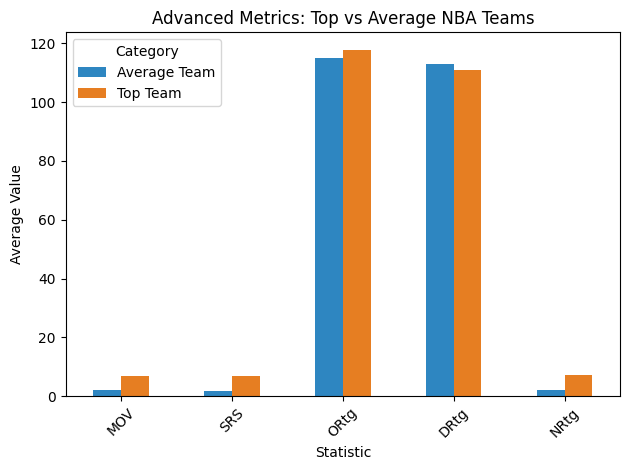

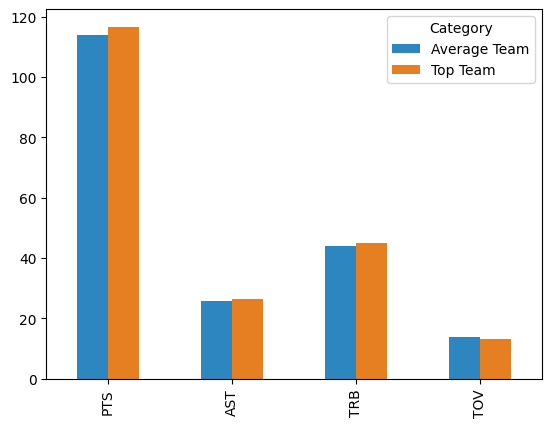

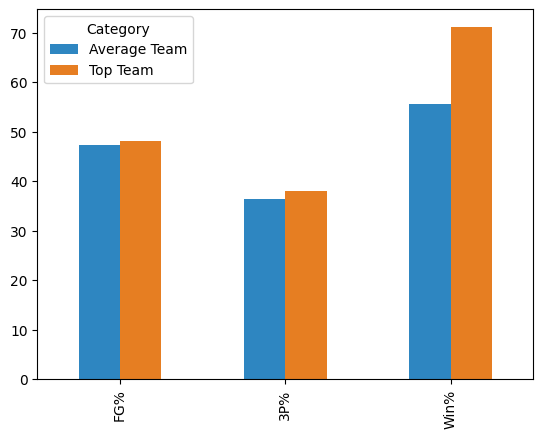